In [133]:
import matplotlib as plt
import pandas as pd
from pymatreader import  read_mat
import numpy as np
import seaborn as sns
from pathlib import Path

# matlab_filename = "output/defaults.mat"
# matlab_filename = "output/no_rock.mat"
matlab_filename = "output/no_water.mat"
# matlab_filename = "output/R_perc_5.mat"

mat_data = read_mat(matlab_filename)
print([key for key in mat_data.keys()])

# Extract some of the values we need to use
deltaT = mat_data["params"]['deltaT'][0]
T0 = mat_data["params"]['T0'][0]
time_mins = [T0 + i*deltaT for i in range(len(mat_data["output_frog_temp"][0]))]

# Skip first day or two
n_days_skip = 2
n_timesteps_skip = int(n_days_skip*24*60/5)
time_mins = time_mins[n_timesteps_skip:]
frog_temps = [frog[n_timesteps_skip:] for frog in mat_data["output_frog_temp"]]
frog_habitats = [frog[n_timesteps_skip:] for frog in mat_data["output_habitats"]]
frog_locations = [frog[n_timesteps_skip:] for frog in mat_data["output_locations"]]

# Plotting
habitat_colours = ["#85522E", "#B8E047", "#14731F", "#1F6BD1"]
habitat_names = mat_data["params"]["habitat_labels"]
habitats_used = np.unique(mat_data["habitat"].astype(int)).tolist()
print(habitats_used)

cmap = plt.colors.ListedColormap(habitat_colours)
palette = dict(zip(habitats_used, [habitat_colours[i-1] for i in habitats_used]))
print(palette)

def save_figure(label):
    fig = plt.pyplot.gcf()
    fig.set_size_inches(6,4)
    lgd = plt.pyplot.gca().get_legend()
    if lgd is None:
        fig.delaxes(fig.axes[-1]) 
    else:
        lgd.remove()
    fig.savefig("figures/" + Path(matlab_filename).stem + "-" + label + ".png")

['__header__', '__version__', '__globals__', 'habitat', 'habitat_temp_profile_hourly', 'output_frog_temp', 'output_habitats', 'output_locations', 'params']
[1, 2, 3]
{1: '#85522E', 2: '#B8E047', 3: '#14731F'}


## Habitat analysis

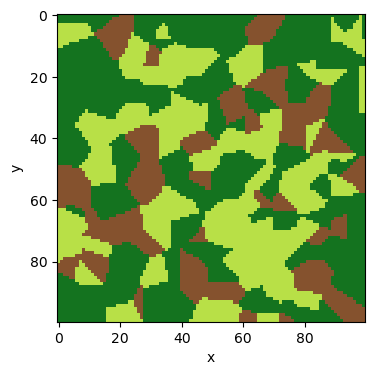

In [134]:
img = plt.pyplot.imshow(
    mat_data["habitat"],
    cmap=cmap,
    vmin=0.5,
    vmax=4.5,
    interpolation="nearest",
    origin="lower"
)
plt.pyplot.gca().invert_yaxis()

cbar = plt.pyplot.colorbar(img, ticks=[1,2,3,4])
cbar.ax.set_yticklabels(habitat_names)

plt.pyplot.xlabel("x")
plt.pyplot.ylabel("y")

save_figure("vegetation_map")

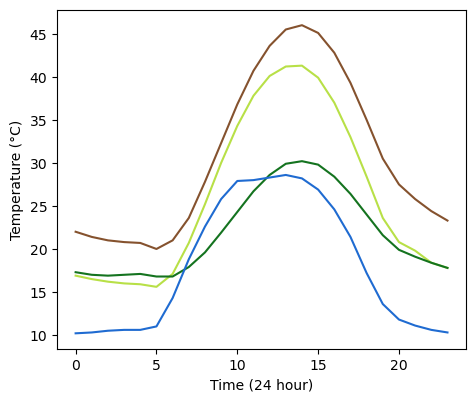

In [135]:
habitat_temp_df = pd.DataFrame(mat_data["habitat_temp_profile_hourly"].T, columns=habitat_names)
ax = habitat_temp_df.plot(color=habitat_colours)
ax.set_xlabel("Time (24 hour)")
ax.set_ylabel("Temperature (°C)")
ax.legend(title="Habitat", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("temperature_profile")

### Habitat distribution per frog

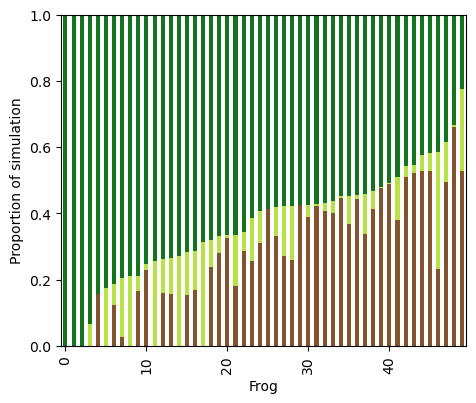

In [136]:
n_timesteps = len(frog_habitats[0])
habitat_counts = [{value: (frog == value).sum()/n_timesteps for value in range(1,5)} for frog in frog_habitats]
habitat_counts = pd.DataFrame(habitat_counts)
habitat_counts = habitat_counts.sort_values(by=[3,1,2,4], ascending=False).reset_index(drop=True)

ax = habitat_counts.plot(kind='bar', stacked=True, color=habitat_colours)
tick_positions = list(range(0, len(habitat_counts), 10))
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_positions)
ax.set_xlabel("Frog")
ax.set_ylabel("Proportion of simulation")
ax.legend(labels = habitat_names, title="Habitat", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()


save_figure("habitat_distribution")

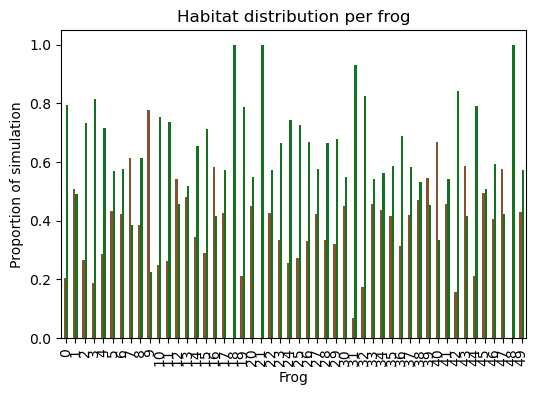

In [137]:
n_timesteps = len(frog_habitats[0])
warm_counts = [(frog <= 2).sum()/n_timesteps for frog in frog_habitats]
cold_counts = [(frog > 2).sum()/n_timesteps for frog in frog_habitats]
habitat_counts = pd.DataFrame({"warm": warm_counts,"cold": cold_counts})

ax = habitat_counts.plot(kind='bar', stacked=False, color=[habitat_colours[i] for i in [0, 2]])
ax.set_xlabel("Frog")
ax.set_ylabel("Proportion of simulation")
ax.set_title("Habitat distribution per frog")

save_figure("warm_cold_distribution")

In [138]:
# Number of habitat changes?

### Residence times

In [139]:
residence_time_df = pd.DataFrame(columns=["frog", "habitat", "residence_time_mins", "entry_time_mins"])
for id,frog_hab in enumerate(frog_habitats):
    hab_change_idxs = np.where(np.diff(frog_hab.astype(int)) != 0) # Skip the first as we won't observe it
    output_df = pd.DataFrame({"residence_time_mins": np.diff(hab_change_idxs)[0]*deltaT})
    output_df["habitat"] = frog_hab[[idx + 1 for idx in hab_change_idxs[0][:-1]]]
    output_df["entry_time_mins"] = [(n_timesteps_skip + idx + 1)*deltaT for idx in hab_change_idxs[0][:-1]]
    output_df["frog"] = id
    residence_time_df = pd.concat([residence_time_df, output_df], ignore_index=True)
print(residence_time_df)

     frog habitat residence_time_mins entry_time_mins
0       0       3                 105            2915
1       0       2                   5            3020
2       0       3                 215            3025
3       0       2                  65            3240
4       0       3                  20            3305
...   ...     ...                 ...             ...
1186   49       1                 225            4655
1187   49       3                 245            4880
1188   49       1                   5            5125
1189   49       3                  40            5130
1190   49       1                   5            5170

[1191 rows x 4 columns]


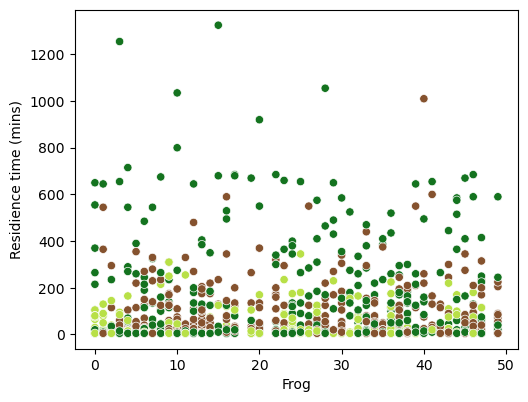

In [140]:
sns.scatterplot(
    data=residence_time_df,
    x="frog",
    y="residence_time_mins",
    hue="habitat",
    palette=palette
)
ax = plt.pyplot.gca()
ax.set_xlabel("Frog")
ax.set_ylabel("Residience time (mins)")
ax.legend(title="Habitat", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("residence_time")

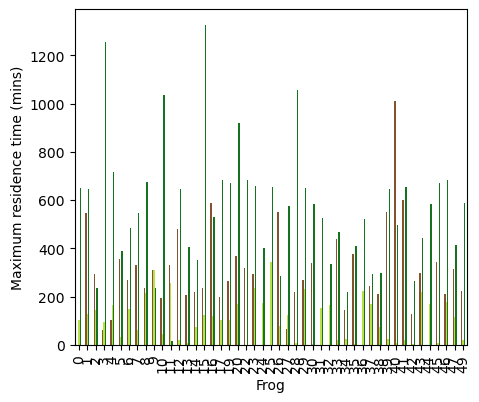

In [141]:
# Maximum residence time
max_residence_df = residence_time_df.groupby(["frog", "habitat"], as_index=False)["residence_time_mins"].max()
max_residence_pivot = max_residence_df.pivot(index="frog", columns="habitat", values="residence_time_mins")

ax = max_residence_pivot.plot(kind="bar", color=[habitat_colours[i-1] for i in habitats_used])
ax.set_xlabel("Frog")
ax.set_ylabel("Maximum residence time (mins)")
ax.legend(labels = [habitat_names[i-1] for i in habitats_used], title="Habitat", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("max_residence_time")

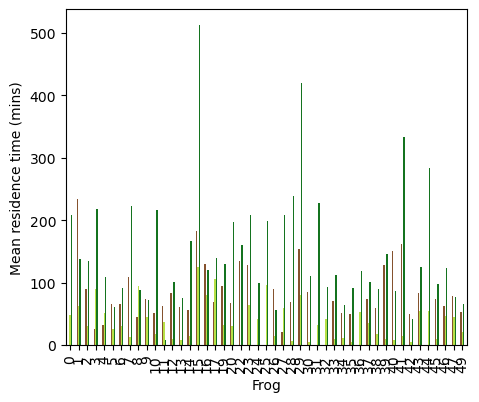

In [142]:
# Average residence time
avg_residence_df = residence_time_df.groupby(["frog", "habitat"], as_index=False)["residence_time_mins"].mean()
avg_residence_pivot = avg_residence_df.pivot(index="frog", columns="habitat", values="residence_time_mins")

ax = avg_residence_pivot.plot(kind="bar", color=[habitat_colours[i-1] for i in habitats_used])
ax.set_xlabel("Frog")
ax.set_ylabel("Mean residence time (mins)")
ax.legend(labels = [habitat_names[i-1] for i in habitats_used], title="Habitat", bbox_to_anchor=(1.02, 0.6), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("avg_residence_time")

## Frog body temperature

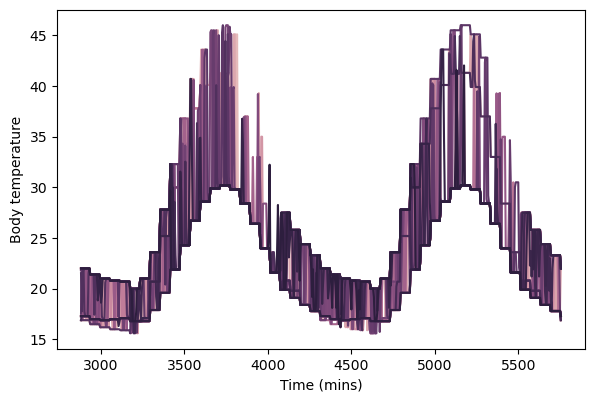

In [143]:
frog_temps_df = pd.concat([pd.DataFrame({"frog": np.ones(len(time_mins), dtype=int)*frog, "time_mins": time_mins, "body_temp": temperature}) 
                           for frog, temperature in enumerate(frog_temps)])

ax = sns.lineplot(
    data=frog_temps_df,
    x="time_mins",
    y="body_temp",
    hue="frog"
)
ax.set_xlabel("Time (mins)")
ax.set_ylabel("Body temperature")
plt.pyplot.tight_layout()

save_figure("body_temp_timeseries")

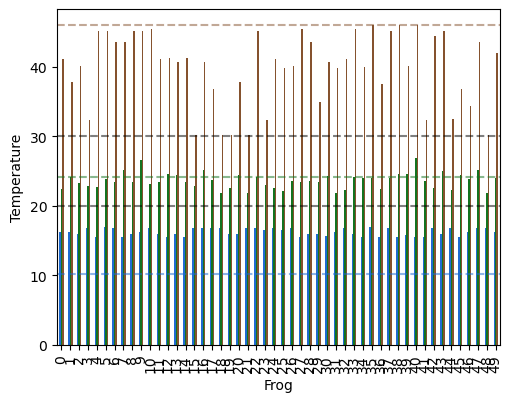

In [144]:
# Calculate the metrics for each frog
frog_temps_max = frog_temps_df.groupby(["frog"], as_index=False)["body_temp"].max()
frog_temps_min = frog_temps_df.groupby(["frog"], as_index=False)["body_temp"].min()
frog_temps_avg = frog_temps_df.groupby(["frog"], as_index=False)["body_temp"].mean()
frog_temps_summary = (
    frog_temps_max.rename(columns={"body_temp": "max"})
    .merge(frog_temps_min.rename(columns={"body_temp": "min"}), on="frog")
    .merge(frog_temps_avg.rename(columns={"body_temp": "avg"}), on="frog")
)

# Colors
col_map = {"min": habitat_colours[3], "avg": habitat_colours[2], "max": habitat_colours[0]}

# Plot
# Add a line for VTmin and VTmax
fig, ax = plt.pyplot.subplots()
ax.axhline(mat_data["params"]["VTmax"][0], color="black", linestyle="--", alpha=0.5)
ax.axhline(mat_data["params"]["VTmin"][0], color="black", linestyle='--', alpha=0.5)

# Now add lines for the min, avg, and max temperatures
temp_flat = [item for sublist in mat_data["habitat_temp_profile_hourly"] for item in sublist]
ax.axhline(np.min(temp_flat), color=col_map["min"], linestyle='--', alpha=0.5)
ax.axhline(np.mean(temp_flat), color=col_map["avg"], linestyle='--', alpha=0.5)
ax.axhline(np.max(temp_flat), color=col_map["max"], linestyle='--', alpha=0.5)

ax = frog_temps_summary.plot(
    x="frog",
    y=["min", "avg", "max"],
    kind="bar",
    color=col_map,
    ax=ax
)
ax.set_xlabel("Frog")
ax.set_ylabel("Temperature")
ax.legend(bbox_to_anchor=(1.02, 0.5), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("body_temp_stats")


## Frog movement

In [145]:
# Create a data frame of frog locations
frog_loc_df = pd.concat([pd.DataFrame({
    "frog": frog_id, "time" : time_mins,
    "x": [x[0] for x in frog_loc_arr], "y": [x[1] for x in frog_loc_arr],
    "RMSD": [np.sqrt((float(x[0]) - float(frog_loc_arr[0][0]))**2 + 
                     (float(x[1]) - float(frog_loc_arr[0][1]))**2) for x in frog_loc_arr]
              }) for frog_id, frog_loc_arr in enumerate(frog_locations)])

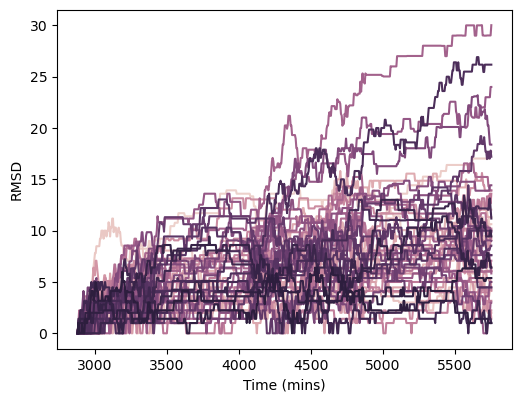

In [146]:
ax = sns.lineplot(
    data=frog_loc_df,
    x="time",
    y="RMSD",
    hue="frog"
)
ax.set_xlabel("Time (mins)")
ax.set_ylabel("RMSD")
ax.legend(title="Frog", bbox_to_anchor=(1.02, 0.5), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("rmsd_timeseries")


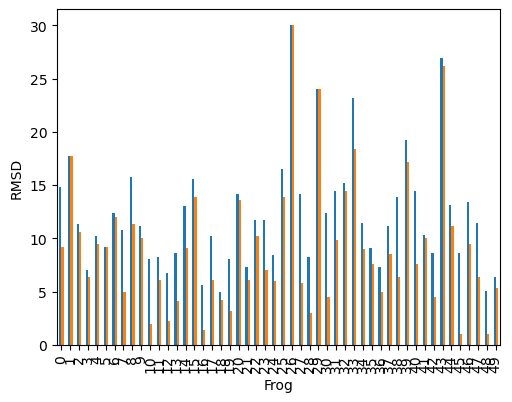

In [147]:
rmsd_summary = frog_loc_df.groupby("frog")["RMSD"].agg(
    max="max",
    final="last"
).reset_index()
ax = rmsd_summary.plot(
    x="frog",
    y=["max", "final"],
    kind="bar"
)
ax.set_xlabel("Frog")
ax.set_ylabel("RMSD")
ax.legend(bbox_to_anchor=(1.02, 0.5), loc="upper left", borderaxespad=0)
plt.pyplot.tight_layout()

save_figure("rmsd_stats")

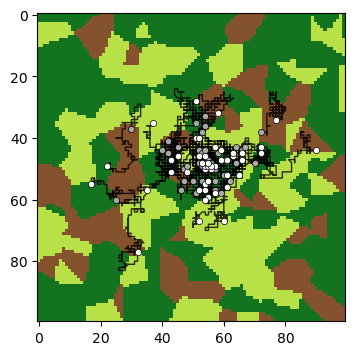

In [148]:
img = plt.pyplot.imshow(
    mat_data["habitat"],
    cmap=cmap,
    vmin=0.5,
    vmax=4.5,
    interpolation="nearest",
    origin="lower"
)

frog_palette = sns.color_palette("husl", n_colors=frog_loc_df["frog"].nunique())
for frog_id, frog_track in frog_loc_df.groupby("frog"):
    plt.pyplot.plot(
        frog_track["x"],
        frog_track["y"],
        # color=frog_palette[int(frog_id)],
        color = "black",
        linewidth=1,
        alpha=0.8
    )
for frog_id, frog_track in frog_loc_df.groupby("frog"):
    plt.pyplot.scatter(
        frog_track["x"].iloc[0],
        frog_track["y"].iloc[0],
        color="darkgrey",
        s=20,
        zorder=5,
        edgecolors="black",
        linewidths=0.5
    )
for frog_id, frog_track in frog_loc_df.groupby("frog"):
    plt.pyplot.scatter(
        frog_track["x"].iloc[-1],
        frog_track["y"].iloc[-1],
        color="white",
        s=20,
        zorder=5,
        edgecolors="black",
        linewidths=0.5
    )

plt.pyplot.gca().invert_yaxis()
cbar = plt.pyplot.colorbar(img, ticks=[1,2,3,4])
cbar.ax.set_yticklabels(mat_data["params"]["habitat_labels"])

save_figure("frog_trails")